In [4]:
import pandas as pd

df = pd.read_csv("final_prepared_data.csv", index_col=0, parse_dates=True)

# Split again
split_index = int(len(df)*0.8)
train = df.iloc[:split_index]
test = df.iloc[split_index:]

C:\Users\PIYUSH\AppData\Local\Temp\ipykernel_2720\924536762.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['anomaly'] = model.predict(train)
C:\Users\PIYUSH\AppData\Local\Temp\ipykernel_2720\924536762.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['anomaly'] = model.predict(test)


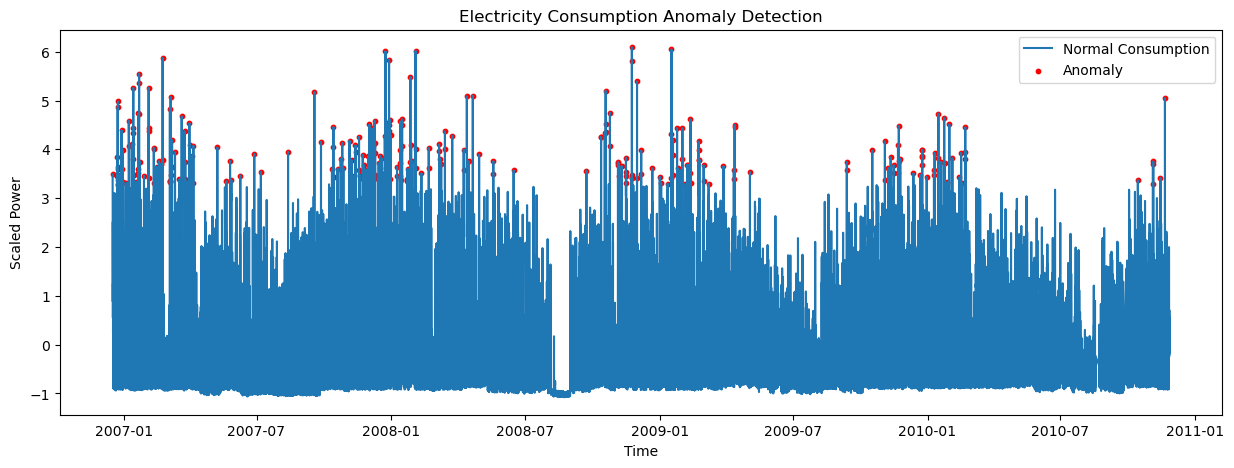

Total anomalies detected: 284


In [5]:
# ===================== ANOMALY DETECTION =====================

# Import model
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# 1) Train Isolation Forest
model = IsolationForest(contamination=0.01, random_state=42)
model.fit(train)

# 2) Predict anomalies
train['anomaly'] = model.predict(train)
test['anomaly'] = model.predict(test)

# Combine back for full timeline
result = pd.concat([train, test])

# 3) Plot anomalies
plt.figure(figsize=(15,5))

# normal data
plt.plot(result.index, result['scaled_power'], label="Normal Consumption")

# anomaly points
anomalies = result[result['anomaly'] == -1]
plt.scatter(anomalies.index, anomalies['scaled_power'], color='red', label="Anomaly", s=10)

plt.title("Electricity Consumption Anomaly Detection")
plt.xlabel("Time")
plt.ylabel("Scaled Power")
plt.legend()
plt.show()

# Count anomalies
print("Total anomalies detected:", (result['anomaly'] == -1).sum())

In [6]:
from sklearn.ensemble import IsolationForest

# Train model ONLY on normal behaviour (train set)
model = IsolationForest(contamination=0.01, random_state=42)
model.fit(train)

# Predict
train['anomaly'] = model.predict(train)
test['anomaly'] = model.predict(test)

C:\Users\PIYUSH\AppData\Local\Temp\ipykernel_2720\2694805897.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['anomaly'] = model.predict(train)
C:\Users\PIYUSH\AppData\Local\Temp\ipykernel_2720\2694805897.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['anomaly'] = model.predict(test)


In [7]:
result = pd.concat([train, test])
result.head()

,scaled_power,anomaly
Datetime,,
2006-12-16 17:00:00,3.488347,-1
2006-12-16 18:00:00,2.830276,1
2006-12-16 19:00:00,2.571848,1
2006-12-16 20:00:00,2.425161,1
2006-12-16 21:00:00,2.188866,1


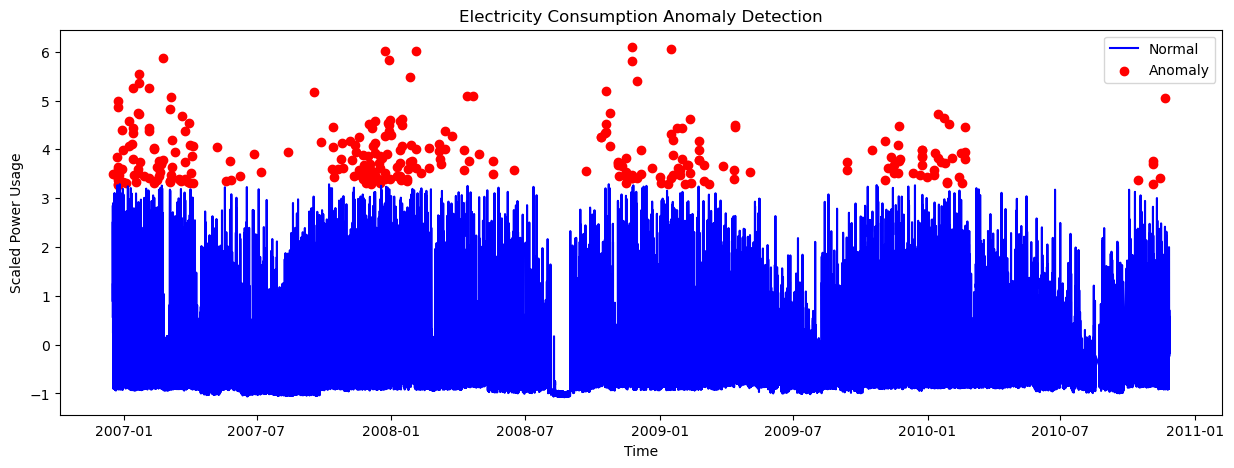

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

# normal data
normal = result[result['anomaly'] == 1]
plt.plot(normal.index, normal['scaled_power'], color='blue', label='Normal')

# anomaly points
anomalies = result[result['anomaly'] == -1]
plt.scatter(anomalies.index, anomalies['scaled_power'], color='red', label='Anomaly')

plt.title("Electricity Consumption Anomaly Detection")
plt.xlabel("Time")
plt.ylabel("Scaled Power Usage")
plt.legend()
plt.show()

In [9]:
print("Total anomalies detected:", len(anomalies))
print("Total data points:", len(result))
print("Percentage anomalous:", (len(anomalies)/len(result))*100, "%")

Total anomalies detected: 284
Total data points: 34168
Percentage anomalous: 0.8311870756263171 %


In [17]:
anomaly_times = anomalies.index
anomaly_times[:100]

DatetimeIndex(['2006-12-16 17:00:00', '2006-12-22 21:00:00',
               '2006-12-23 08:00:00', '2006-12-23 15:00:00',
               '2006-12-23 16:00:00', '2006-12-23 17:00:00',
               '2006-12-23 19:00:00', '2006-12-23 20:00:00',
               '2006-12-23 22:00:00', '2006-12-23 23:00:00',
               '2006-12-24 00:00:00', '2006-12-25 22:00:00',
               '2006-12-28 21:00:00', '2006-12-29 21:00:00',
               '2006-12-30 10:00:00', '2006-12-31 08:00:00',
               '2007-01-04 12:00:00', '2007-01-07 18:00:00',
               '2007-01-07 21:00:00', '2007-01-11 19:00:00',
               '2007-01-13 20:00:00', '2007-01-13 21:00:00',
               '2007-01-13 22:00:00', '2007-01-13 23:00:00',
               '2007-01-14 17:00:00', '2007-01-17 10:00:00',
               '2007-01-20 13:00:00', '2007-01-20 18:00:00',
               '2007-01-20 19:00:00', '2007-01-21 19:00:00',
               '2007-01-21 20:00:00', '2007-01-21 21:00:00',
               '2007-01-

In [18]:
len(anomaly_times)

284

In [19]:
print(anomaly_times.to_list())

[Timestamp('2006-12-16 17:00:00'), Timestamp('2006-12-22 21:00:00'), Timestamp('2006-12-23 08:00:00'), Timestamp('2006-12-23 15:00:00'), Timestamp('2006-12-23 16:00:00'), Timestamp('2006-12-23 17:00:00'), Timestamp('2006-12-23 19:00:00'), Timestamp('2006-12-23 20:00:00'), Timestamp('2006-12-23 22:00:00'), Timestamp('2006-12-23 23:00:00'), Timestamp('2006-12-24 00:00:00'), Timestamp('2006-12-25 22:00:00'), Timestamp('2006-12-28 21:00:00'), Timestamp('2006-12-29 21:00:00'), Timestamp('2006-12-30 10:00:00'), Timestamp('2006-12-31 08:00:00'), Timestamp('2007-01-04 12:00:00'), Timestamp('2007-01-07 18:00:00'), Timestamp('2007-01-07 21:00:00'), Timestamp('2007-01-11 19:00:00'), Timestamp('2007-01-13 20:00:00'), Timestamp('2007-01-13 21:00:00'), Timestamp('2007-01-13 22:00:00'), Timestamp('2007-01-13 23:00:00'), Timestamp('2007-01-14 17:00:00'), Timestamp('2007-01-17 10:00:00'), Timestamp('2007-01-20 13:00:00'), Timestamp('2007-01-20 18:00:00'), Timestamp('2007-01-20 19:00:00'), Timestamp('20